In [32]:
import os
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim

import random
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("./data")
IMAGE_SIZE = 28
CHANNELS_IMG = 1
Z_DIM = 100
NUM_CLASSES = 10  # 10 digits (0-9) for MNIST
EMBEDDING_DIM = 50  # Embedding dimension for class labels
BATCH_SIZE = 128
RANDOM_SEED = 42
LEARNING_RATE = 2e-4
NUM_EPOCHS = 10




NUM_WORKERS = 8
PERSISTENT_WORKERS = True
CHECKPOINT_DIR = Path("./checkpoints")


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [33]:
def set_seed(seed: int = RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def show_images(batch, n: int = 25):
    images = batch[:n].detach().cpu()
    grid_size = int(n ** 0.5)

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size, grid_size))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis("off")
            continue
        ax.imshow(images[i, 0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def show_images_with_labels(batch, labels, n: int = 25):
    images = batch[:n].detach().cpu()
    labels = labels[:n].detach().cpu()
    grid_size = int(n ** 0.5)

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size * 1.2, grid_size * 1.2))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis("off")
            continue
        ax.imshow(images[i, 0], cmap="gray")
        ax.set_title(f"{labels[i].item()}", fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def generate_specific_digits(generator, digits, num_samples_per_digit=5):
    generator.eval()
    
    # Create labels
    labels = []
    for digit in digits:
        labels.extend([digit] * num_samples_per_digit)
    
    labels = torch.tensor(labels, device=DEVICE)
    num_total = len(labels)
    
    # Generate noise
    noise = torch.randn(num_total, Z_DIM, device=DEVICE)
    
    # Generate images
    with torch.no_grad():
        fake_imgs = generator(noise, labels)
    
    print(f"Generated {num_total} images for digits: {digits}")
    print(f"Labels: {labels.cpu().numpy()}")
    
    return fake_imgs, labels

# def weights_init(m):
#     if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
#         nn.init.normal_(m.weight.data, 0.0, 0.02)
#         if m.bias is not None:
#             nn.init.constant_(m.bias.data, 0.0)
#     elif isinstance(m, nn.BatchNorm2d):
#         nn.init.normal_(m.weight.data, 1.0, 0.02)
#         nn.init.constant_(m.bias.data, 0.0)


set_seed()


Using device: cpu
Batch size: 64
Number of workers: 0
Batch images shape: torch.Size([64, 1, 28, 28])
Batch labels shape: torch.Size([64])
Number of training samples: 60000


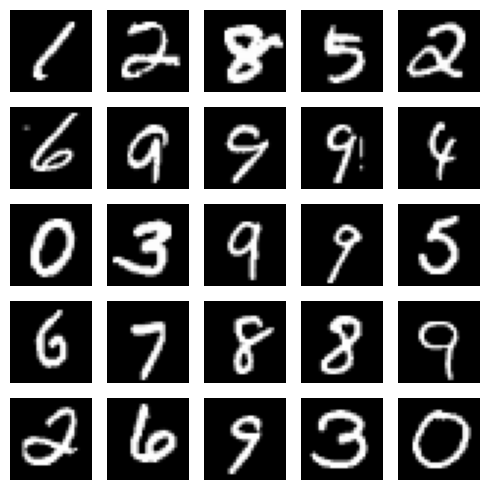

In [ ]:
if DEVICE.type == "cpu":
    BATCH_SIZE = 64
    NUM_WORKERS = 0
    PERSISTENT_WORKERS = False

print(f"Using device: {DEVICE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of workers: {NUM_WORKERS}")

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(
    root="datasets",
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    # persistent_workers=True,
)
real_imgs, real_labels = next(iter(train_loader))
print("Batch images shape:", real_imgs.shape)
print("Batch labels shape:", real_labels.shape)
print(f"Number of training samples: {len(train_dataset)}")

show_images_with_labels(real_imgs, real_labels)


In [35]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Embedding for class labels
        self.label_embedding = nn.Embedding(NUM_CLASSES, IMAGE_SIZE * IMAGE_SIZE)
        
        # Input: image (1 channel) + label embedding (1 channel) = 2 channels
        self.net = nn.Sequential(
            nn.Conv2d(2, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 1),
            nn.Sigmoid(),
        )

    def forward(self, x, labels):
        # Embed labels and reshape to image format
        label_embed = self.label_embedding(labels)  # [N, 784]
        label_embed = label_embed.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE)  # [N, 1, 28, 28]
        
        # Concatenate image and label embedding
        x = torch.cat([x, label_embed], dim=1)  # [N, 2, 28, 28]
        return self.net(x)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Embedding for class labels
        self.label_embedding = nn.Embedding(NUM_CLASSES, EMBEDDING_DIM)
        
        # Input: noise (Z_DIM) + label embedding (EMBEDDING_DIM)
        self.fc = nn.Sequential(
            nn.Linear(Z_DIM + EMBEDDING_DIM, 128 * 7 * 7),
            nn.ReLU(inplace=True),
        )

        self.conv = nn.Sequential(
            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=3),
            nn.Sigmoid(),
        )

    def forward(self, z, labels):
        # Embed labels
        label_embed = self.label_embedding(labels)  # [N, EMBEDDING_DIM]
        
        # Concatenate noise and label embedding
        x = torch.cat([z, label_embed], dim=1)  # [N, Z_DIM + EMBEDDING_DIM]
        x = self.fc(x)                           # [N, 128*7*7]
        x = x.view(-1, 128, 7, 7)                # [N, 128, 7, 7]
        x = self.conv(x)                         # [N, 1, 28, 28]
        return x


discriminator = Discriminator().to(DEVICE)
generator = Generator().to(DEVICE)

# discriminator.apply(weights_init)
# generator.apply(weights_init)

print(discriminator)
print(generator)


Discriminator(
  (label_embedding): Embedding(10, 784)
  (net): Sequential(
    (0): Conv2d(2, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=1, bias=True)
    (8): Sigmoid()
  )
)
Generator(
  (label_embedding): Embedding(10, 50)
  (fc): Sequential(
    (0): Linear(in_features=150, out_features=6272, bias=True)
    (1): ReLU(inplace=True)
  )
  (conv): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [36]:
criterion = nn.BCELoss()

optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE)
optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE)

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

losses_D = []
losses_G = []



for epoch in range(NUM_EPOCHS):
    generator.train()
    discriminator.train()

    running_loss_D = 0.0
    running_loss_G = 0.0

    for batch_idx, (real_imgs, class_labels) in enumerate(train_loader):
        real_imgs = real_imgs.to(DEVICE)
        class_labels = class_labels.to(DEVICE)  # Now we use the actual class labels!
        batch_size = real_imgs.size(0)

        # ============================
        # Train Discriminator
        # ============================
        discriminator.zero_grad()

        # Real images, label = 1
        labels_real = torch.ones(batch_size, 1, device=DEVICE)
        outputs_real = discriminator(real_imgs, class_labels)
        loss_real = criterion(outputs_real, labels_real)

        # Fake images, label = 0
        noise = torch.randn(batch_size, Z_DIM, device=DEVICE)
        fake_imgs = generator(noise, class_labels)
        labels_fake = torch.zeros(batch_size, 1, device=DEVICE)
        outputs_fake = discriminator(fake_imgs.detach(), class_labels)
        loss_fake = criterion(outputs_fake, labels_fake)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # ============================
        # Train Generator
        # ============================
        generator.zero_grad()

        noise = torch.randn(batch_size, Z_DIM, device=DEVICE)
        fake_imgs = generator(noise, class_labels)
        # Generator wants discriminator to output 1 (real)
        labels_gen = torch.ones(batch_size, 1, device=DEVICE)
        outputs = discriminator(fake_imgs, class_labels)
        loss_G = criterion(outputs, labels_gen)

        loss_G.backward()
        optimizer_G.step()

        running_loss_D += loss_D.item()
        running_loss_G += loss_G.item()

        if (batch_idx + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
                f"Batch [{batch_idx+1}/{len(train_loader)}] "
                f"Loss_D: {loss_D.item():.4f} "
                f"Loss_G: {loss_G.item():.4f}")


    avg_loss_D = running_loss_D / len(train_loader)
    avg_loss_G = running_loss_G / len(train_loader)

    losses_D.append(avg_loss_D)
    losses_G.append(avg_loss_G)


    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  "
          f"Loss_D: {avg_loss_D:.4f}  Loss_G: {avg_loss_G:.4f}")

    # Save checkpoint at the end of each epoch
    checkpoint_path = CHECKPOINT_DIR / f"gan_epoch_{epoch+1}.pt"
    torch.save({
        "epoch": epoch + 1,
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "optimizer_G_state_dict": optimizer_G.state_dict(),
        "optimizer_D_state_dict": optimizer_D.state_dict(),
    }, checkpoint_path)

    print(f"Saved checkpoint: {checkpoint_path}")

KeyboardInterrupt: 

In [ ]:
plt.plot(losses_D, label="Discriminator loss")
plt.plot(losses_G, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("GAN Training Loss")
plt.show()

In [ ]:
# Generate 25 images of digit "3"
fake_imgs, labels = generate_specific_digits(generator, [3], num_samples_per_digit=25)
show_images_with_labels(fake_imgs, labels, n=25)

# Generate 5 of each digit 0-9
fake_imgs, labels = generate_specific_digits(generator, list(range(10)), num_samples_per_digit=5)
show_images_with_labels(fake_imgs, labels, n=50)

# Generate mixed digits
fake_imgs, labels = generate_specific_digits(generator, [1, 5, 9], num_samples_per_digit=10)
show_images_with_labels(fake_imgs, labels, n=30)